# Architecture 3 — Prompt Profiling Pipeline

**Pipeline:**  
Prompt text → MiniLM-L6-v2 embeddings → StandardScaler → MultiOutputRegressor(XGBRegressor) → predicts D1, D2, D3, D5 → D4 Rule Engine → Complexity Score → Tier Assignment

This notebook implements the full end-to-end pipeline including:
1. Data Loading & Preprocessing
2. D4 Rule Engine
3. Sentence Embeddings (all-MiniLM-L6-v2)
4. Train/Test Split & Scaling
5. MultiOutput XGBoost Training
6. Evaluation (per-dimension + tier accuracy)
7. Reusable Inference Function
8. Visualizations
9. Model Persistence

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report, accuracy_score
)
from sklearn.metrics.pairwise import cosine_similarity

from xgboost import XGBRegressor
from sentence_transformers import SentenceTransformer

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)

print("All imports successful.")

All imports successful.


---
## Helper Functions

These two functions are used throughout the notebook:
- `complexity_score()` — weighted composite of all five dimensions
- `get_tier()` — maps a complexity score to T1/T2/T3

In [2]:
def complexity_score(d1, d2, d3, d4, d5):
    """Compute weighted complexity score from five dimension scores."""
    return (d1 * 0.35) + (d2 * 0.20) + (d3 * 0.20) + (d4 * 0.15) + (d5 * 0.10)


def get_tier(score):
    """Map a complexity score to a tier label."""
    if score < 0.40:
        return 'T1'
    elif score < 0.70:
        return 'T2'
    else:
        return 'T3'


# Quick sanity check
assert get_tier(0.10) == 'T1'
assert get_tier(0.50) == 'T2'
assert get_tier(0.85) == 'T3'
print("Helper functions defined and verified.")

Helper functions defined and verified.


---
## Step 1 — Data Loading & Preprocessing

Load the CSV dataset containing 470 prompts with columns: `id`, `prompt`, `phrasing_style`, `domain`, `d1`–`d5`.

**Tier extraction strategy:**
1. Try to extract tier from the `id` column using regex `_(t[123])_` (case-insensitive)
2. For rows where extraction fails, derive tier from the complexity score
3. Fix any label/score mismatches by trusting the derived tier over extracted tier

In [3]:
# ── Load CSV ─────────────────────────────────────────────────────────────────
df = pd.read_csv('/content/dataset_prompt_profiling.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (470, 9)
Columns: ['id', 'prompt', 'phrasing_style', 'domain', 'd1', 'd2', 'd3', 'd4', 'd5']


,id,prompt,phrasing_style,domain,d1,d2,d3,d4,d5
0,day2_t1_gap_001,what does mqtt stand for and why do iot devices use it instead of http,explicit,IoT & Smart Factory,0.25,0.50,0.25,0.00,0.00
1,day2_t1_gap_002,"the syslog file attached is showing error code 0x4F on the assembly arm PLC, what does that mean",implicit,IoT & Smart Factory,0.00,0.50,0.00,0.25,0.25
2,day2_t1_gap_003,modbus rtu vs modbus tcp what is the main difference,vague,IoT & Smart Factory,0.25,0.50,0.25,0.00,0.00
3,day2_t1_gap_004,how do I reboot a generic smart sensor if it loses factory network connection,explicit,IoT & Smart Factory,0.00,0.25,0.25,0.00,0.00
4,day2_t1_gap_005,"our factory floor monitors are lagging compared to the control room, are we supposed to use webs...",implicit,IoT & Smart Factory,0.25,0.50,0.00,0.00,0.00


In [4]:
# ── Basic data checks ────────────────────────────────────────────────────────
print(f"Null counts:\n{df.isnull().sum()}")
print(f"\nDimension score ranges:")
for col in ['d1', 'd2', 'd3', 'd4', 'd5']:
    print(f"  {col}: [{df[col].min()}, {df[col].max()}]")

Null counts:
id                0
prompt            0
phrasing_style    0
domain            0
d1                0
d2                0
d3                0
d4                0
d5                0
dtype: int64

Dimension score ranges:
  d1: [0.0, 1.0]
  d2: [0.0, 1.0]
  d3: [0.0, 1.0]
  d4: [0.0, 1.0]
  d5: [0.0, 0.75]


In [5]:
# ── Tier extraction from id column ───────────────────────────────────────────
def extract_tier_from_id(row_id):
    """Extract tier from id using regex pattern _(t[123])_ (case-insensitive)."""
    match = re.search(r'_(t[123])_', str(row_id), re.IGNORECASE)
    if match:
        return match.group(1).upper()
    return None


df['tier_extracted'] = df['id'].apply(extract_tier_from_id)

extracted_count = df['tier_extracted'].notna().sum()
missing_count = df['tier_extracted'].isna().sum()
print(f"Tier extracted from id: {extracted_count} rows")
print(f"Tier NOT extractable:   {missing_count} rows")

Tier extracted from id: 173 rows
Tier NOT extractable:   297 rows


In [6]:
# ── Compute complexity score & derive tier for ALL rows ─────────────────────
df['complexity_score'] = df.apply(
    lambda r: complexity_score(r['d1'], r['d2'], r['d3'], r['d4'], r['d5']), axis=1
)
df['tier_derived'] = df['complexity_score'].apply(get_tier)

# For rows where extraction failed → use derived tier
df['tier'] = df['tier_extracted'].fillna(df['tier_derived'])

print(f"Tier distribution (before mismatch fix):")
print(df['tier'].value_counts().sort_index())

Tier distribution (before mismatch fix):
tier
T1    171
T2    154
T3    145
Name: count, dtype: int64


In [7]:
# ── Fix label/score mismatches ───────────────────────────────────────────────
# Trust scores over labels: if extracted tier != derived tier, override with derived
mismatch_mask = (df['tier_extracted'].notna()) & (df['tier_extracted'] != df['tier_derived'])
mismatch_count = mismatch_mask.sum()
print(f"Rows where extracted tier != derived tier: {mismatch_count}")

if mismatch_count > 0:
    print("\nSample mismatches:")
    print(df.loc[mismatch_mask, ['id', 'tier_extracted', 'tier_derived', 'complexity_score']].head(10))

# Override: trust derived tier for ALL rows
df['tier'] = df['tier_derived']

print(f"\nFinal tier distribution (after mismatch fix):")
print(df['tier'].value_counts().sort_index())
print(f"\nTotal rows: {len(df)}")

Rows where extracted tier != derived tier: 21

Sample mismatches:
                 id tier_extracted tier_derived  complexity_score
69  day2_t2_gap_001             T2           T1            0.3250
70  day2_t2_gap_002             T2           T1            0.3250
72  day2_t2_gap_004             T2           T1            0.2750
80  day2_t2_gap_012             T2           T1            0.3875
83  day2_t2_gap_015             T2           T1            0.3500
85  day2_t2_gap_017             T2           T1            0.3500
86  day2_t2_gap_018             T2           T1            0.3500
91  day2_t2_gap_023             T2           T1            0.2750
94  day2_t2_gap_026             T2           T1            0.3250
97  day2_t2_gap_029             T2           T1            0.2750

Final tier distribution (after mismatch fix):
tier
T1    188
T2    141
T3    141
Name: count, dtype: int64

Total rows: 470


In [8]:
# ── Summary after preprocessing ──────────────────────────────────────────────
print(f"DataFrame shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df[['id', 'prompt', 'd1', 'd2', 'd3', 'd4', 'd5', 'complexity_score', 'tier']].head(10)

DataFrame shape: (470, 13)

Columns: ['id', 'prompt', 'phrasing_style', 'domain', 'd1', 'd2', 'd3', 'd4', 'd5', 'tier_extracted', 'complexity_score', 'tier_derived', 'tier']


,id,prompt,d1,d2,d3,d4,d5,complexity_score,tier
0,day2_t1_gap_001,what does mqtt stand for and why do iot devices use it instead of http,0.25,0.50,0.25,0.00,0.00,0.2375,T1
1,day2_t1_gap_002,"the syslog file attached is showing error code 0x4F on the assembly arm PLC, what does that mean",0.00,0.50,0.00,0.25,0.25,0.1625,T1
2,day2_t1_gap_003,modbus rtu vs modbus tcp what is the main difference,0.25,0.50,0.25,0.00,0.00,0.2375,T1
3,day2_t1_gap_004,how do I reboot a generic smart sensor if it loses factory network connection,0.00,0.25,0.25,0.00,0.00,0.1000,T1
4,day2_t1_gap_005,"our factory floor monitors are lagging compared to the control room, are we supposed to use webs...",0.25,0.50,0.00,0.00,0.00,0.1875,T1
5,day2_t1_gap_006,why is my smart gateway blinking red twice,0.00,0.25,0.00,0.00,0.00,0.0500,T1
6,day2_t1_gap_007,"based on the factory sensor log attached, what was the highest recorded temperature of the cnc m...",0.00,0.50,0.25,0.25,0.25,0.2125,T1
7,day2_t1_gap_008,"shop floor tablets losing signal, 2.4ghz or 5ghz wifi",0.25,0.25,0.00,0.00,0.00,0.1375,T1
8,day2_t1_gap_009,wifi vs ethernet for factory floor cnc machines pros cons list,0.25,0.25,0.25,0.00,0.00,0.1875,T1
9,day2_t1_gap_010,"look at this screenshot of the SCADA dashboard, which sensor is currently reporting an offline s...",0.00,0.50,0.00,0.25,0.25,0.1625,T1


---
## Step 2 — D4 Rule Engine

D4 (External Data Dependency) is determined by **rule-based keyword matching** rather than ML.

Priority order (first match wins):
- **1.0**: market research, competitive analysis, analyst report, industry trends, industry report
- **0.75**: latest, recent, current, pricing, market, forecast, survey, compare vendors
- **0.50**: compare, evaluate, benchmark, analysis, study
- **0.0**: otherwise

In [9]:
def get_d4(prompt):
    """Rule-based D4 score using case-insensitive substring matching.

    Priority order (first match wins):
      1.0  → market research, competitive analysis, analyst report,
             industry trends, industry report
      0.75 → latest, recent, current, pricing, market,
             forecast, survey, compare vendors
      0.50 → compare, evaluate, benchmark, analysis, study
      0.0  → otherwise
    """
    text = prompt.lower()

    # Priority 1: D4 = 1.0
    keywords_1 = ["market research", "competitive analysis", "analyst report",
                  "industry trends", "industry report"]
    if any(kw in text for kw in keywords_1):
        return 1.0

    # Priority 2: D4 = 0.75
    keywords_075 = ["latest", "recent", "current", "pricing", "market",
                    "forecast", "survey", "compare vendors"]
    if any(kw in text for kw in keywords_075):
        return 0.75

    # Priority 3: D4 = 0.50
    keywords_050 = ["compare", "evaluate", "benchmark", "analysis", "study"]
    if any(kw in text for kw in keywords_050):
        return 0.50

    # Default
    return 0.0


# Apply rule engine to all prompts
df['d4_rule'] = df['prompt'].apply(get_d4)

# Compute MAE between d4_rule and ground-truth d4
d4_mae = mean_absolute_error(df['d4'], df['d4_rule'])
print(f"D4 Rule Engine MAE vs ground-truth: {d4_mae:.4f}")

# Show distribution of rule-based D4 scores
print(f"\nD4 rule-based score distribution:")
print(df['d4_rule'].value_counts().sort_index())

# Show some examples
print(f"\nSample rows with D4 comparison:")
df[['prompt', 'd4', 'd4_rule']].sample(5, random_state=42)

D4 Rule Engine MAE vs ground-truth: 0.2835

D4 rule-based score distribution:
d4_rule
0.00    388
0.50     16
0.75     64
1.00      2
Name: count, dtype: int64

Sample rows with D4 comparison:


,prompt,d4,d4_rule
55,"google ads vs meta ads for local reach, which is cheaper",0.00,0.00
73,I have uploaded our draft cloud architecture design for\nour new AWS multi-region payment gatewa...,0.25,0.75
33,casual vs business casual dress code rules,0.00,0.00
446,our facebook ads conversions are way off from what ga4 is tracking and it's messing with our bid...,0.75,0.00
425,Draft an enterprise architecture specification for a centralized AI gateway that enforces rate l...,0.75,0.00


---
## Step 3 — Sentence Embeddings

Use `all-MiniLM-L6-v2` from SentenceTransformers to encode all 470 prompts into 384-dimensional dense vectors.
These embeddings capture semantic meaning and serve as input features for the XGBoost model.

In [10]:
# ── Generate embeddings ──────────────────────────────────────────────────────
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

prompts = df['prompt'].tolist()
embeddings = embed_model.encode(prompts, show_progress_bar=True, batch_size=64)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Embedding dtype:  {embeddings.dtype}")
print(f"Sample embedding (first 10 dims): {embeddings[0][:10]}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Embeddings shape: (470, 384)
Embedding dtype:  float32
Sample embedding (first 10 dims): [-0.06259057  0.05965592  0.01803835  0.02005261 -0.01226598 -0.07437382
 -0.00091021  0.02330992  0.0467933   0.00991498]


---
## Step 4 — Train/Test Split & Scaling

- **Features (X):** 384-dim MiniLM embeddings
- **Targets (y):** D1, D2, D3, D5 (D4 is rule-based, excluded from ML)
- **Split:** 80/20, stratified by tier, `random_state=42`
- **Scaling:** StandardScaler on X only (not y)

In [11]:
# ── Prepare features and targets ─────────────────────────────────────────────
X = embeddings  # (470, 384)
y = df[['d1', 'd2', 'd3', 'd5']].values  # D4 excluded (rule-based)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Target columns: d1, d2, d3, d5")

X shape: (470, 384)
y shape: (470, 4)
Target columns: d1, d2, d3, d5


In [12]:
# ── Train/Test split ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index,
    test_size=0.20,
    stratify=df['tier'],
    random_state=42
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")
print(f"\nTier distribution in train set:")
print(df.loc[idx_train, 'tier'].value_counts().sort_index())
print(f"\nTier distribution in test set:")
print(df.loc[idx_test, 'tier'].value_counts().sort_index())

X_train: (376, 384)  |  X_test: (94, 384)
y_train: (376, 4)  |  y_test: (94, 4)

Tier distribution in train set:
tier
T1    150
T2    113
T3    113
Name: count, dtype: int64

Tier distribution in test set:
tier
T1    38
T2    28
T3    28
Name: count, dtype: int64


In [13]:
# ── Scale features ───────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled  shape: {X_test_scaled.shape}")
print(f"\nPost-scaling stats (train):")
print(f"  Mean ~ {X_train_scaled.mean():.6f}")
print(f"  Std  ~ {X_train_scaled.std():.6f}")

X_train_scaled shape: (376, 384)
X_test_scaled  shape: (94, 384)

Post-scaling stats (train):
  Mean ~ -0.000000
  Std  ~ 1.000000


---
## Step 5 — Train MultiOutput XGBoost

- **Base estimator:** `XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)`
- **Wrapper:** `MultiOutputRegressor` for simultaneous prediction of D1, D2, D3, D5
- **Post-processing:** Clip all outputs to [0.0, 1.0]

In [14]:
# ── Train model ──────────────────────────────────────────────────────────────
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

multi_model = MultiOutputRegressor(estimator=xgb_base)
multi_model.fit(X_train_scaled, y_train)

print("Model training complete.")
print(f"Number of sub-estimators: {len(multi_model.estimators_)}")
print(f"Targets: D1, D2, D3, D5")

Model training complete.
Number of sub-estimators: 4
Targets: D1, D2, D3, D5


In [15]:
# ── Predict & clip ───────────────────────────────────────────────────────────
y_pred_raw = multi_model.predict(X_test_scaled)
y_pred = np.clip(y_pred_raw, 0.0, 1.0)

print(f"Predictions shape: {y_pred.shape}")
print(f"Prediction range before clip: [{y_pred_raw.min():.4f}, {y_pred_raw.max():.4f}]")
print(f"Prediction range after clip:  [{y_pred.min():.4f}, {y_pred.max():.4f}]")

# Preview
pred_df = pd.DataFrame(y_pred, columns=['d1_pred', 'd2_pred', 'd3_pred', 'd5_pred'])
pred_df.head()

Predictions shape: (94, 4)
Prediction range before clip: [-0.0026, 0.9978]
Prediction range after clip:  [0.0000, 0.9978]


,d1_pred,d2_pred,d3_pred,d5_pred
0,0.432250,0.400055,0.117407,0.077301
1,0.702490,0.635172,0.659831,0.395626
2,0.791273,0.693919,0.753293,0.599441
3,0.188027,0.553501,0.147977,0.113401
4,0.635076,0.644519,0.646336,0.363469


---
## Step 6 — Evaluation

### Per-dimension metrics: MAE, RMSE, R² for D1, D2, D3, D5

### Tier accuracy:
- **Predicted tier:** model's D1/D2/D3/D5 predictions + `d4_rule` for D4 → complexity_score → get_tier()
- **Actual tier:** ground-truth d1–d5 (using ground-truth d4, NOT d4_rule) → complexity_score → get_tier()

In [16]:
# ── Per-dimension metrics ────────────────────────────────────────────────────
dim_names = ['D1', 'D2', 'D3', 'D5']
metrics_results = {}

print("Per-Dimension Metrics (Test Set)")
print("=" * 50)
for i, dim in enumerate(dim_names):
    mae  = mean_absolute_error(y_test[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_pred[:, i]))
    r2   = r2_score(y_test[:, i], y_pred[:, i])
    metrics_results[dim] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    print(f"  {dim}:  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")

print("=" * 50)

Per-Dimension Metrics (Test Set)
  D1:  MAE=0.1596  RMSE=0.2073  R²=0.6785
  D2:  MAE=0.1668  RMSE=0.2026  R²=0.4132
  D3:  MAE=0.1711  RMSE=0.2256  R²=0.5929
  D5:  MAE=0.1355  RMSE=0.1716  R²=0.5565


In [17]:
# ── Tier prediction ──────────────────────────────────────────────────────────
# ACTUAL tier: ground-truth d1-d5 → complexity_score → get_tier
test_df = df.loc[idx_test].copy().reset_index(drop=True)

actual_complexity = test_df.apply(
    lambda r: complexity_score(r['d1'], r['d2'], r['d3'], r['d4'], r['d5']), axis=1
)
actual_tiers = actual_complexity.apply(get_tier)

# PREDICTED tier: predicted D1/D2/D3/D5 + d4_rule for D4 → complexity_score → get_tier
pred_d4_rule = test_df['d4_rule'].values

pred_complexity = np.array([
    complexity_score(y_pred[i, 0], y_pred[i, 1], y_pred[i, 2], pred_d4_rule[i], y_pred[i, 3])
    for i in range(len(y_pred))
])
pred_tiers = pd.Series(pred_complexity).apply(get_tier)

# Tier accuracy
tier_acc = accuracy_score(actual_tiers, pred_tiers)
print(f"Tier Accuracy: {tier_acc:.4f} ({tier_acc*100:.2f}%)")

Tier Accuracy: 0.6596 (65.96%)


In [18]:
# ── Confusion matrix & classification report ─────────────────────────────────
tier_labels = ['T1', 'T2', 'T3']

cm = confusion_matrix(actual_tiers, pred_tiers, labels=tier_labels)
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=tier_labels, columns=tier_labels))

print(f"\nClassification Report:")
print(classification_report(actual_tiers, pred_tiers, labels=tier_labels, zero_division=0))

Confusion Matrix:
    T1  T2  T3
T1  35   3   0
T2   0  25   3
T3   4  22   2

Classification Report:
              precision    recall  f1-score   support

          T1       0.90      0.92      0.91        38
          T2       0.50      0.89      0.64        28
          T3       0.40      0.07      0.12        28

    accuracy                           0.66        94
   macro avg       0.60      0.63      0.56        94
weighted avg       0.63      0.66      0.59        94



---
## Step 7 — Reusable Inference Function

A self-contained function that takes a raw prompt string and returns:
- Predicted tier (T1/T2/T3)
- Individual dimension scores (D1–D5)
- Complexity score
- Top 3 similar training prompts (cosine similarity)

In [19]:
def profile_prompt(prompt_text, embed_model, scaler, model, df_train, X_train_scaled):
    """
    Profile a single prompt through the full Architecture 3 pipeline.

    Parameters
    ----------
    prompt_text : str
        The raw prompt to profile.
    embed_model : SentenceTransformer
        The embedding model (all-MiniLM-L6-v2).
    scaler : StandardScaler
        Fitted scaler for feature normalization.
    model : MultiOutputRegressor
        Trained multi-output XGBoost model.
    df_train : pd.DataFrame
        Training dataframe (for retrieving similar prompts).
    X_train_scaled : np.ndarray
        Scaled training embeddings (for cosine similarity search).

    Returns
    -------
    dict with keys:
        tier, complexity_score, d1, d2, d3, d4_rule, d4_final, d5,
        tier_probabilities (raw complexity score), top3_similar_prompts
    """
    # 1. Embed the prompt
    emb = embed_model.encode([prompt_text])

    # 2. Scale
    emb_scaled = scaler.transform(emb)

    # 3. Predict D1, D2, D3, D5 via ML model
    preds = model.predict(emb_scaled)
    preds = np.clip(preds, 0.0, 1.0)
    d1_pred, d2_pred, d3_pred, d5_pred = preds[0]

    # 4. D4 via rule engine
    d4_rule_val = get_d4(prompt_text)

    # 5. D4 final: max(predicted_d4_from_knn_fallback, d4_rule)
    #    Since this architecture has no KNN, d4_final = d4_rule
    d4_final = d4_rule_val

    # 6. Complexity score & tier
    cs = complexity_score(d1_pred, d2_pred, d3_pred, d4_final, d5_pred)
    tier = get_tier(cs)

    # 7. Top 3 similar prompts (cosine similarity on scaled embeddings)
    similarities = cosine_similarity(emb_scaled, X_train_scaled)[0]
    top3_idx = np.argsort(similarities)[-3:][::-1]
    top3_prompts = df_train.iloc[top3_idx]['prompt'].tolist()
    top3_scores = similarities[top3_idx].tolist()

    return {
        'tier': tier,
        'tier_probabilities': cs,  # raw complexity score (regression, not classification)
        'd1': round(float(d1_pred), 4),
        'd2': round(float(d2_pred), 4),
        'd3': round(float(d3_pred), 4),
        'd4_rule': d4_rule_val,
        'd4_final': d4_final,
        'd5': round(float(d5_pred), 4),
        'complexity_score': round(float(cs), 4),
        'top3_similar_prompts': [
            {'prompt': p, 'similarity': round(s, 4)}
            for p, s in zip(top3_prompts, top3_scores)
        ]
    }


print("Inference function defined.")

Inference function defined.


In [20]:
# ── Prepare training dataframe for inference ─────────────────────────────────
df_train = df.loc[idx_train].reset_index(drop=True)
print(f"df_train shape: {df_train.shape}")

df_train shape: (376, 14)


In [21]:
# ── Test Prompt 1 ────────────────────────────────────────────────────────────
test_prompts = [
    "why is our AWS bill so high this month",
    "build a full GenAI cost attribution platform with market research across AWS, Azure and GCP pricing",
    "set up SSO between okta and our internal tool"
]

for i, prompt in enumerate(test_prompts, 1):
    print(f"\n{'='*80}")
    print(f"TEST PROMPT {i}: \"{prompt}\"")
    print(f"{'='*80}")

    result = profile_prompt(
        prompt_text=prompt,
        embed_model=embed_model,
        scaler=scaler,
        model=multi_model,
        df_train=df_train,
        X_train_scaled=X_train_scaled
    )

    print(f"  Tier:             {result['tier']}")
    print(f"  Complexity Score: {result['complexity_score']}")
    print(f"  D1 (Scope):       {result['d1']}")
    print(f"  D2 (Specificity): {result['d2']}")
    print(f"  D3 (Cross-domain):{result['d3']}")
    print(f"  D4 (Rule-based):  {result['d4_rule']}")
    print(f"  D4 (Final):       {result['d4_final']}")
    print(f"  D5 (Output):      {result['d5']}")
    print(f"\n  Top 3 Similar Training Prompts:")
    for j, sim in enumerate(result['top3_similar_prompts'], 1):
        print(f"    {j}. [sim={sim['similarity']:.4f}] {sim['prompt'][:100]}...")


TEST PROMPT 1: "why is our AWS bill so high this month"
  Tier:             T1
  Complexity Score: 0.1299
  D1 (Scope):       0.1541
  D2 (Specificity): 0.2919
  D3 (Cross-domain):0.0785
  D4 (Rule-based):  0.0
  D4 (Final):       0.0
  D5 (Output):      0.0189

  Top 3 Similar Training Prompts:
    1. [sim=0.6514] AWS bills are going crazy again and we have no idea who is spinning up these huge instances, someone...
    2. [sim=0.5125] our cloud bill is double what it was last quarter and nobody can
explain it...
    3. [sim=0.5072] can you explain this line from the aws bill attached?...

TEST PROMPT 2: "build a full GenAI cost attribution platform with market research across AWS, Azure and GCP pricing"
  Tier:             T3
  Complexity Score: 0.7472
  D1 (Scope):       0.7467
  D2 (Specificity): 0.7236
  D3 (Cross-domain):0.7815
  D4 (Rule-based):  1.0
  D4 (Final):       1.0
  D5 (Output):      0.3485

  Top 3 Similar Training Prompts:
    1. [sim=0.3442] The executive board wan

---
## Step 8 — Visualizations

### 8.1 Tier distribution (actual vs predicted)
### 8.2 Confusion matrix heatmap
### 8.3 Actual vs Predicted scatter plots (D1, D2, D3, D5)
### 8.4 Distribution plots (actual vs predicted/rule-based)
### 8.5 XGBoost feature importance (top 20 embedding dims)

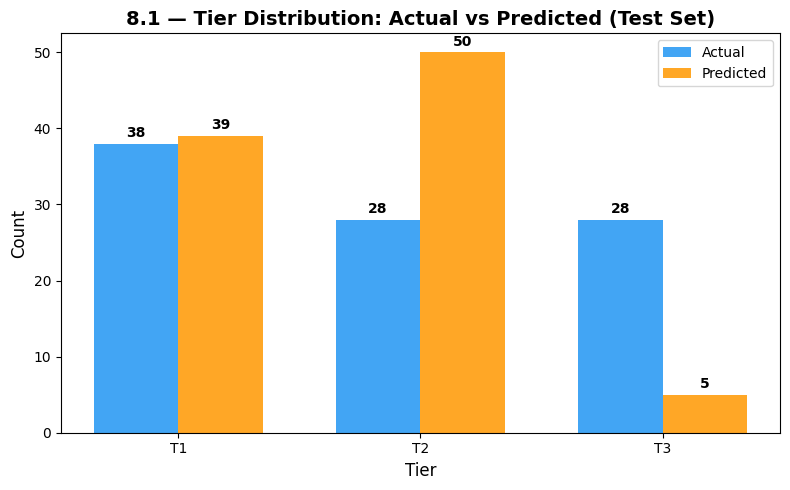

Saved: viz_8_1_tier_distribution.png


In [22]:
# ── 8.1 Tier Distribution: Actual vs Predicted ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

actual_counts = actual_tiers.value_counts().reindex(tier_labels, fill_value=0)
pred_counts = pred_tiers.value_counts().reindex(tier_labels, fill_value=0)

x = np.arange(len(tier_labels))
width = 0.35

bars1 = ax.bar(x - width/2, actual_counts.values, width, label='Actual', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, pred_counts.values, width, label='Predicted', color='#FF9800', alpha=0.85)

ax.set_xlabel('Tier', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('8.1 — Tier Distribution: Actual vs Predicted (Test Set)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(tier_labels)
ax.legend()

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('viz_8_1_tier_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_8_1_tier_distribution.png")

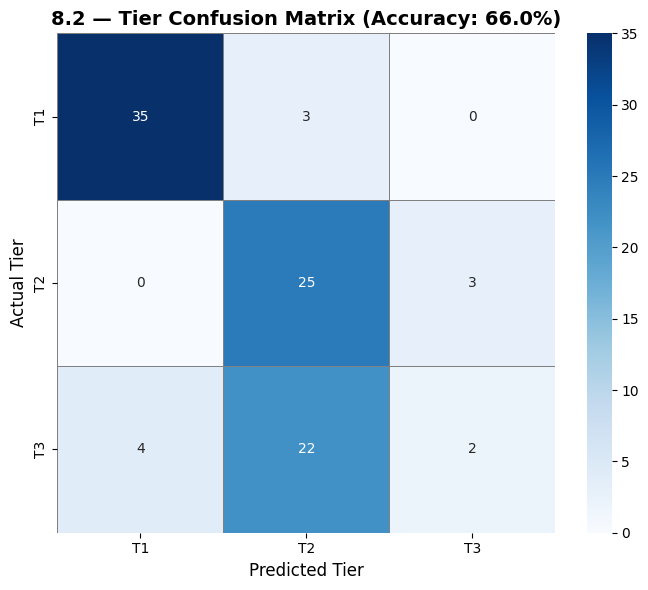

Saved: viz_8_2_confusion_matrix.png


In [23]:
# ── 8.2 Confusion Matrix Heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=tier_labels, yticklabels=tier_labels,
            linewidths=0.5, linecolor='gray', ax=ax)

ax.set_xlabel('Predicted Tier', fontsize=12)
ax.set_ylabel('Actual Tier', fontsize=12)
ax.set_title(f'8.2 — Tier Confusion Matrix (Accuracy: {tier_acc*100:.1f}%)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_8_2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_8_2_confusion_matrix.png")

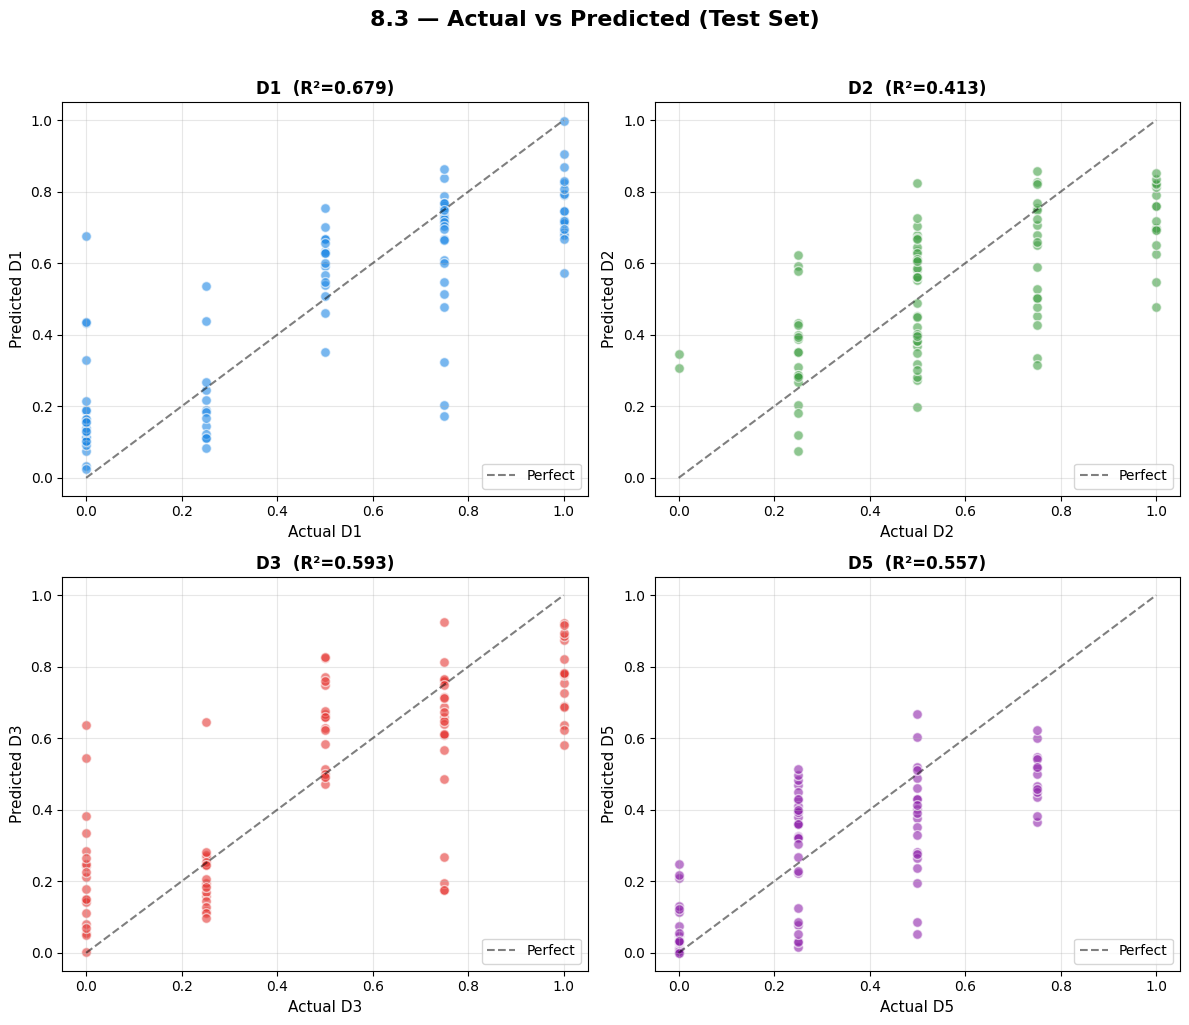

Saved: viz_8_3_scatter_plots.png


In [24]:
# ── 8.3 Actual vs Predicted Scatter Plots (2×2 grid) ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('8.3 — Actual vs Predicted (Test Set)', fontsize=16, fontweight='bold', y=1.02)

colors = ['#1E88E5', '#43A047', '#E53935', '#8E24AA']

for i, (dim, color) in enumerate(zip(dim_names, colors)):
    ax = axes[i // 2][i % 2]

    ax.scatter(y_test[:, i], y_pred[:, i], alpha=0.6, color=color, edgecolors='white', s=50)

    # Perfect prediction line
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1.5, label='Perfect')

    ax.set_xlabel(f'Actual {dim}', fontsize=11)
    ax.set_ylabel(f'Predicted {dim}', fontsize=11)
    ax.set_title(f'{dim}  (R²={metrics_results[dim]["R²"]:.3f})', fontsize=12, fontweight='bold')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('viz_8_3_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_8_3_scatter_plots.png")

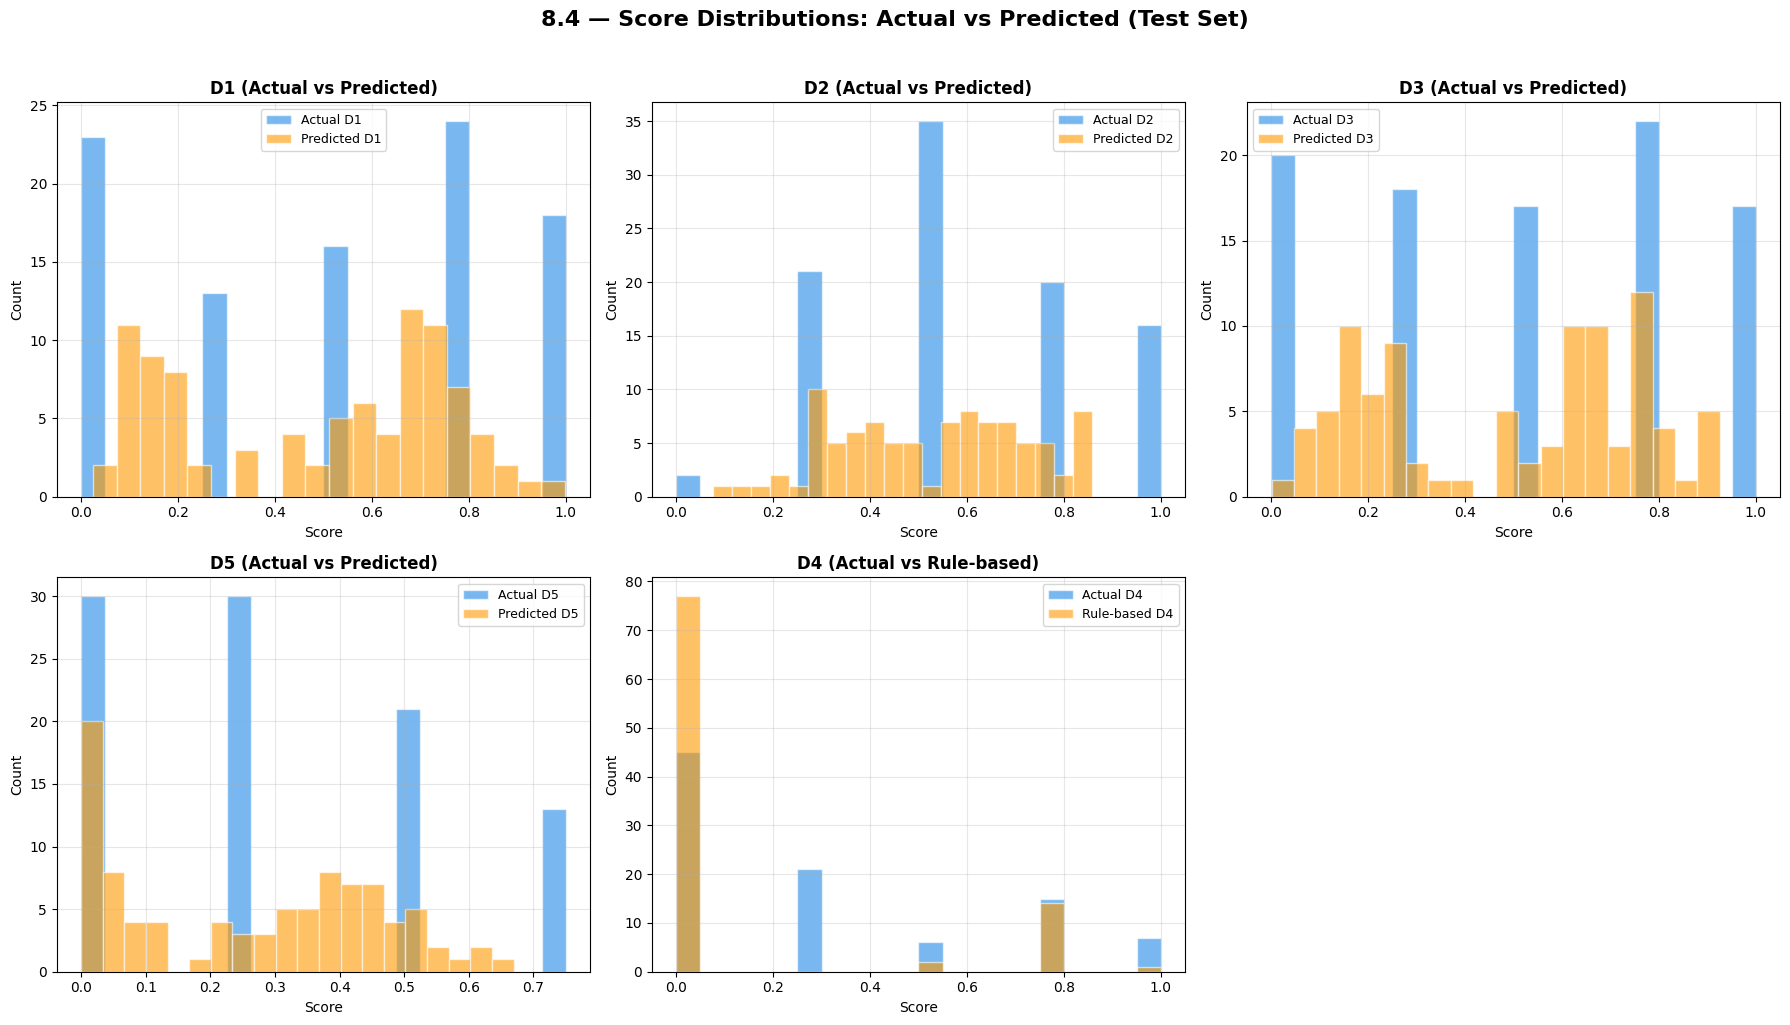

Saved: viz_8_4_distribution_plots.png


In [25]:
# ── 8.4 Distribution Plots: Actual vs Predicted/Rule-based ───────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('8.4 — Score Distributions: Actual vs Predicted (Test Set)',
             fontsize=16, fontweight='bold', y=1.02)

# D1, D2, D3, D5 — ML predicted
all_dims = ['D1', 'D2', 'D3', 'D5', 'D4']
plot_positions = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)]

for idx, (dim, pos) in enumerate(zip(all_dims, plot_positions)):
    ax = axes[pos[0]][pos[1]]

    if dim == 'D4':
        # D4: actual vs rule-based
        ax.hist(test_df['d4'], bins=20, alpha=0.6, label='Actual D4', color='#1E88E5', edgecolor='white')
        ax.hist(test_df['d4_rule'], bins=20, alpha=0.6, label='Rule-based D4', color='#FF9800', edgecolor='white')
        ax.set_title(f'{dim} (Actual vs Rule-based)', fontsize=12, fontweight='bold')
    else:
        # ML dimensions
        ml_idx = ['D1', 'D2', 'D3', 'D5'].index(dim)
        ax.hist(y_test[:, ml_idx], bins=20, alpha=0.6, label=f'Actual {dim}', color='#1E88E5', edgecolor='white')
        ax.hist(y_pred[:, ml_idx], bins=20, alpha=0.6, label=f'Predicted {dim}', color='#FF9800', edgecolor='white')
        ax.set_title(f'{dim} (Actual vs Predicted)', fontsize=12, fontweight='bold')

    ax.set_xlabel('Score', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide unused subplot
axes[1][2].set_visible(False)

plt.tight_layout()
plt.savefig('viz_8_4_distribution_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_8_4_distribution_plots.png")

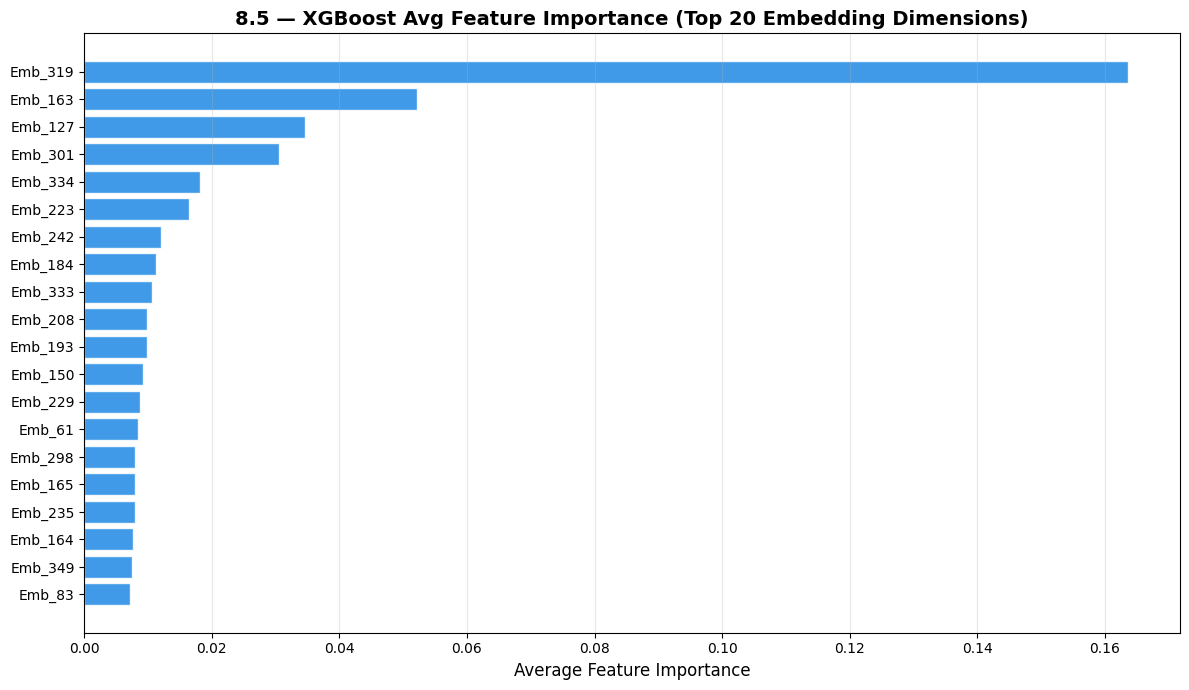

Saved: viz_8_5_feature_importance.png


In [26]:
# ── 8.5 XGBoost Feature Importance (Top 20 Embedding Dims) ───────────────────
# Average feature importance across all 4 regressors
importances = np.zeros(X_train_scaled.shape[1])
for est in multi_model.estimators_:
    importances += est.feature_importances_
importances /= len(multi_model.estimators_)

# Get top 20
top20_idx = np.argsort(importances)[-20:][::-1]
top20_vals = importances[top20_idx]
top20_labels = [f'Emb_{i}' for i in top20_idx]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(len(top20_labels)), top20_vals[::-1], color='#1E88E5', alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(top20_labels)))
ax.set_yticklabels(top20_labels[::-1], fontsize=10)
ax.set_xlabel('Average Feature Importance', fontsize=12)
ax.set_title('8.5 — XGBoost Avg Feature Importance (Top 20 Embedding Dimensions)',
             fontsize=14, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('viz_8_5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_8_5_feature_importance.png")

---
## Step 9 — Model Persistence

Save the trained model and scaler using joblib for future inference.

In [27]:
# ── Save models ──────────────────────────────────────────────────────────────
joblib.dump(multi_model, 'xgb_multioutput_model.joblib')
joblib.dump(scaler, 'scaler.joblib')

print("Models saved:")
print("  → xgb_multioutput_model.joblib")
print("  → scaler.joblib")

Models saved:
  → xgb_multioutput_model.joblib
  → scaler.joblib


In [28]:
# ── Final Summary Table ──────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("        FINAL SUMMARY — Architecture 3 Results")
print("=" * 60)
print(f"{'Dimension':<12} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 40)

for dim in dim_names:
    m = metrics_results[dim]
    print(f"{dim:<12} {m['MAE']:>8.4f} {m['RMSE']:>8.4f} {m['R²']:>8.4f}")

print("-" * 40)
print(f"{'Tier Acc.':<12} {tier_acc*100:>7.2f}%")
print(f"{'D4 Rule MAE':<12} {d4_mae:>8.4f}")
print("=" * 60)


        FINAL SUMMARY — Architecture 3 Results
Dimension         MAE     RMSE       R²
----------------------------------------
D1             0.1596   0.2073   0.6785
D2             0.1668   0.2026   0.4132
D3             0.1711   0.2256   0.5929
D5             0.1355   0.1716   0.5565
----------------------------------------
Tier Acc.      65.96%
D4 Rule MAE    0.2835


In [29]:
# ── Verify saved models load correctly ───────────────────────────────────────
loaded_model = joblib.load('xgb_multioutput_model.joblib')
loaded_scaler = joblib.load('scaler.joblib')

# Quick verification: predict on first test sample
verify_pred = loaded_model.predict(loaded_scaler.transform(X_test[:1]))
verify_pred = np.clip(verify_pred, 0.0, 1.0)
print(f"Model load verification — prediction on first test sample:")
print(f"  D1={verify_pred[0][0]:.4f}, D2={verify_pred[0][1]:.4f}, "
      f"D3={verify_pred[0][2]:.4f}, D5={verify_pred[0][3]:.4f}")
print("\n✅ Architecture 3 pipeline complete!")

Model load verification — prediction on first test sample:
  D1=0.4322, D2=0.4001, D3=0.1174, D5=0.0773

✅ Architecture 3 pipeline complete!
